# 02 · Machine Learning — CAFV Classifier & Range Regressor

## Problems
1. **CAFV Eligibility Classifier** (3-class) — 41% of records are 'unknown'. Can we predict eligibility from vehicle attributes?
2. **Electric Range Regressor** — Given make, year, and EV type, can we predict range better than a simple group-median baseline?

All modelling uses XGBoost. SHAP is used for explainability.

In [5]:
import sys, warnings
sys.path.insert(0, "..")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import shap
import plotly.express as px
import plotly.graph_objects as go
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt
from pathlib import Path

from src.features import full_preprocessing_pipeline
from src.models import train_cafv_classifier, train_range_regressor, save_model
from src import visualizations as viz

DATA_PATH = Path("../data/raw/Electric_Vehicle_Population_Data.csv")
MODEL_DIR = Path("../data/models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

df = full_preprocessing_pipeline(DATA_PATH)
print(f"Dataset shape: {df.shape}")


Dropped 199,320 duplicate rows


Dataset shape: (81513, 19)


## 1 · CAFV Eligibility Classifier

**Target classes:**
- `0` → eligible (46.4%)
- `1` → not_eligible (12.6%)
- `2` → unknown (41.0%)

**Key constraint**: `Electric Range` IS available for known records but is 0 for unknowns. This is intentionally included as a feature — it's one of the strongest signals.

In [6]:
results_cafv = train_cafv_classifier(df, random_state=42)
model_cafv = results_cafv["model"]
save_model(model_cafv, MODEL_DIR, "cafv_classifier")

cv_scores = results_cafv["cv_scores"]
print(f"\nCV F1-macro: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")



CV F1-macro: 1.0000 ± 0.0000


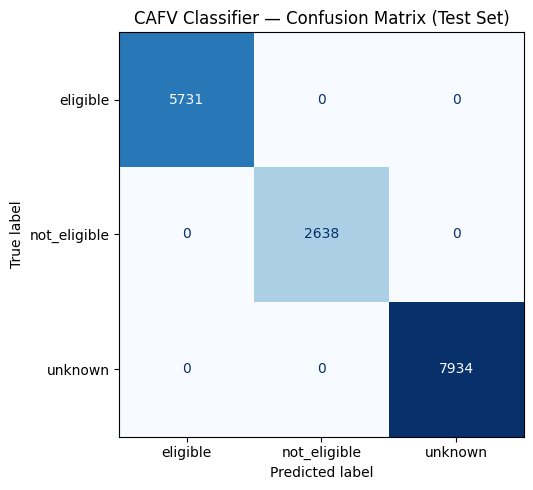

In [7]:
# Confusion matrix
cm = confusion_matrix(results_cafv["y_test"], results_cafv["model"].predict(results_cafv["X_test"]))
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(cm, display_labels=["eligible", "not_eligible", "unknown"])
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("CAFV Classifier — Confusion Matrix (Test Set)")
plt.tight_layout()
plt.show()


In [8]:
# SHAP explainability — CAFV classifier
explainer_cafv = shap.TreeExplainer(model_cafv)
shap_vals_cafv = explainer_cafv.shap_values(results_cafv["X_test"].sample(2000, random_state=42))

# Mean |SHAP| across all classes
import numpy as np
mean_shap = pd.Series(
    np.abs(np.array(shap_vals_cafv)).mean(axis=(0, 2))
    if isinstance(shap_vals_cafv, list) else np.abs(shap_vals_cafv).mean(axis=0),
    index=results_cafv["X_test"].columns,
    name="mean_shap"
)
viz.plot_shap_bar(mean_shap, title="CAFV Classifier — Feature Importance (mean |SHAP|)")


ValueError: Data must be 1-dimensional, got ndarray of shape (7, 3) instead

In [ ]:
# SHAP beeswarm for class 0 (eligible)
shap.summary_plot(
    shap_vals_cafv[0] if isinstance(shap_vals_cafv, list) else shap_vals_cafv,
    results_cafv["X_test"].sample(2000, random_state=42),
    plot_type="dot",
    show=True,
    max_display=10,
)


## 2 · Electric Range Regressor

Only non-zero range records are used (zero = unverified, not real zero range).

In [ ]:
results_range = train_range_regressor(df, random_state=42)
model_range = results_range["model"]
save_model(model_range, MODEL_DIR, "range_regressor")

m = results_range["metrics"]
print(f"\nRange Regressor Results:")
print(f"  MAE  : {m['mae']:.2f} miles   (baseline: {m['baseline_mae']:.2f} miles)")
print(f"  RMSE : {m['rmse']:.2f} miles")
print(f"  R²   : {m['r2']:.4f}")
print(f"  Improvement over baseline MAE: {(1 - m['mae']/m['baseline_mae'])*100:.1f}%")


In [ ]:
viz.plot_residuals(
    results_range["y_test"],
    results_range["y_pred"],
    title="Range Regressor — Residual Plot (Test Set)"
)


In [ ]:
# SHAP for range regressor
explainer_range = shap.TreeExplainer(model_range)
X_sample = results_range["X_test"].sample(2000, random_state=42)
shap_vals_range = explainer_range.shap_values(X_sample)

mean_shap_range = pd.Series(
    np.abs(shap_vals_range).mean(axis=0),
    index=X_sample.columns,
    name="mean_shap",
)
viz.plot_shap_bar(mean_shap_range, title="Range Regressor — Feature Importance (mean |SHAP|)")


In [ ]:
shap.summary_plot(shap_vals_range, X_sample, plot_type="dot", show=True, max_display=8)


## 3 · Predicted CAFV for 'Unknown' Records

Apply the trained classifier to the 53,446 'unknown' records to estimate how many are likely eligible vs not eligible.

In [ ]:
from src.models import CAFV_FEATURES

unknown_mask = df["cafv_label"] == "unknown"
df_unknown = df[unknown_mask][CAFV_FEATURES].copy()

preds = model_cafv.predict(df_unknown)
pred_proba = model_cafv.predict_proba(df_unknown)

pred_series = pd.Series(preds, index=df_unknown.index)
print("Predicted CAFV class distribution for 'unknown' records:")
counts = pred_series.value_counts().rename({0: "eligible", 1: "not_eligible", 2: "unknown"})
print(counts)
print()
print(f"Of the {unknown_mask.sum():,} 'unknown' records, "
      f"~{(preds == 0).sum():,} ({100*(preds==0).mean():.1f}%) are predicted eligible.")
